In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import sys
import os

# Define the path to the directory containing the modules
module_path = '/content/drive/My Drive/Kernel_GLM_bis'

# Add the directory to the Python path
if os.path.exists(module_path):
    sys.path.append(module_path)
    print(f"'{module_path}' added to Python path. You can now import modules from this directory.")
else:
    print(f"Error: Directory '{module_path}' not found. Please check the path.")

'/content/drive/My Drive/Kernel_GLM_bis' added to Python path. You can now import modules from this directory.


In [3]:
!pip install pykeops > install.log


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from math import*
import pandas as pd

from rkhs_glm_scaled_KeOps import RKHSGLM_KeOps

from pseudo_label_experiment_general_KeOps import FAMILIES, make_data, mean, KGLM_covariate_shift, a_logpartition, run_experiment

import os
import sys

import torch, os
from pykeops.torch import LazyTensor
torch.set_default_dtype(torch.float32)
torch.set_float32_matmul_precision("high")


# (Optional) keep BLAS quiet on CPU if you still do any host ops
#os.environ["OMP_NUM_THREADS"] = "1"
#os.environ["OPENBLAS_NUM_THREADS"] = "1"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
# before creating any tensors/models:
torch.set_num_threads(min(8, torch.get_num_threads() or 8))  # or your core count
torch.set_num_interop_threads(1)
os.environ["CUDA_VISIBLE_DEVICES"] = ""

os.environ["OMP_NUM_THREADS"] = "8"      # set to your physical cores
os.environ["MKL_NUM_THREADS"] = "8"
os.environ["OPENBLAS_NUM_THREADS"] = "8"
os.environ["NUMEXPR_NUM_THREADS"] = "8"

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.
Device: cpu


In [5]:
base = module_path
outdir = os.path.join(base, "results_poisson_torchcpu_1_5_cos_0_45_shift")
os.makedirs(outdir, exist_ok=True)  # creates it if missing

In [ ]:
outdir

'/content/drive/My Drive/Kernel_GLM_bis/results_poisson_torchcpu_1_5_cos_0_45_shift'

In [6]:
fcn = lambda x: 1.5*np.cos(2*np.pi*x)

In [ ]:
beta = 2 # ratio parameter in the grid of lambdas
seed = 100 # random seed
rng = np.random.default_rng(seed)


n = 4000 # number of source samples
n_0 = n # number of unlabeled target samples
#B = 22 # parameter of distribution shift
B = n ** (0.45)
fcn = lambda x: 1.5*np.cos(2*np.pi*x)
#fcn = lambda x: 6*np.abs(0.5- x) - 1.5

test = KGLM_covariate_shift(n, n_0, B, fcn=fcn, family='poisson', kernel='sobolev_intercept', seed=seed)
test.fit(beta = beta)

KeyboardInterrupt: 

Target excess risks: estimated by Monte Carlo method, report means and standard errors
Naive: 0.02782154083251953 (0.009610756635665893)
Pseudo-Labeling: 0.021570473909378052 (0.009516605734825134)
Oracle: 0.012946173548698425 (0.009718744158744812)

Selected lambdas: 
Naive: 0.0008
Pseudo-Labeling: 5e-05
Oracle: 0.0002


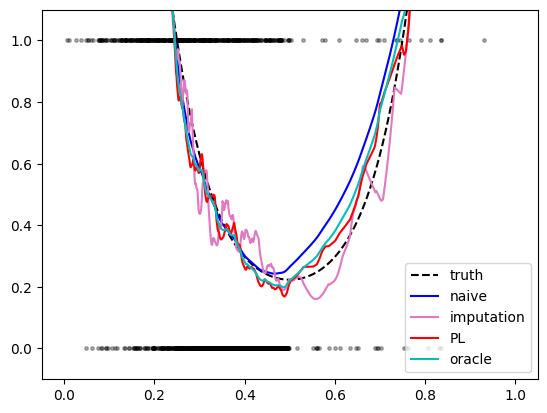

In [ ]:
# Visualization and evaluation of selected models
# True function: black dashed line
# Source data: gray dots
# Naive method (hold-out validation using source data): blue
# Imputation model (undersmoothed): pink
# New method (hold-out validation with pseudo-labels): red
# Oracle method (validation with noiseless true labels): cyan


#####################
# visualization
X_new = np.arange(0, 1, 0.001) # grid
test.predict_final(X_new)

fig, ax = plt.subplots()
xlim = [-0.05, 1.05]
ylim = [-0.1, 9.1]

plt.ylim(ylim)
plt.xlim(xlim)
plt.plot(test.X_1, test.y_1, 'k.', alpha = 0.3, markersize = 5, label = '_nolegend_')
plt.plot(X_new, test.mean_new_true, 'k--', label = 'truth')
plt.plot(X_new, test.mean_new_naive, 'b-', label = 'naive')
plt.plot(X_new, test.mean_new_tilde, color = 'tab:pink', label = 'imputation')
plt.plot(X_new, test.mean_new_pseudo, 'r-', label = 'PL')
plt.plot(X_new, test.mean_new_real, 'c-', label = 'oracle')

plt.legend(loc = 'lower right')
#ax.set_aspect( (xlim[1] - xlim[0]) / (ylim[1] - ylim[0]) )


#####################
# evaluation
N_test = 10000
test.evaluate_final(N_test = N_test, seed = seed)
print('Target excess risks: estimated by Monte Carlo method, report means and standard errors')
print('Naive: {} ({})'.format(test.err_naive, test.err_naive_ste))
print('Pseudo-Labeling: {} ({})'.format(test.err_pseudo, test.err_pseudo_ste))
print('Oracle: {} ({})'.format(test.err_real, test.err_real_ste))


# report selected lambdas
lbds = [test.lbd_naive, test.lbd_pseudo, test.lbd_real]
print('')
print('Selected lambdas: ')
print('Naive: {}'.format(lbds[0]))
print('Pseudo-Labeling: {}'.format(lbds[1]))
print('Oracle: {}'.format(lbds[2]))

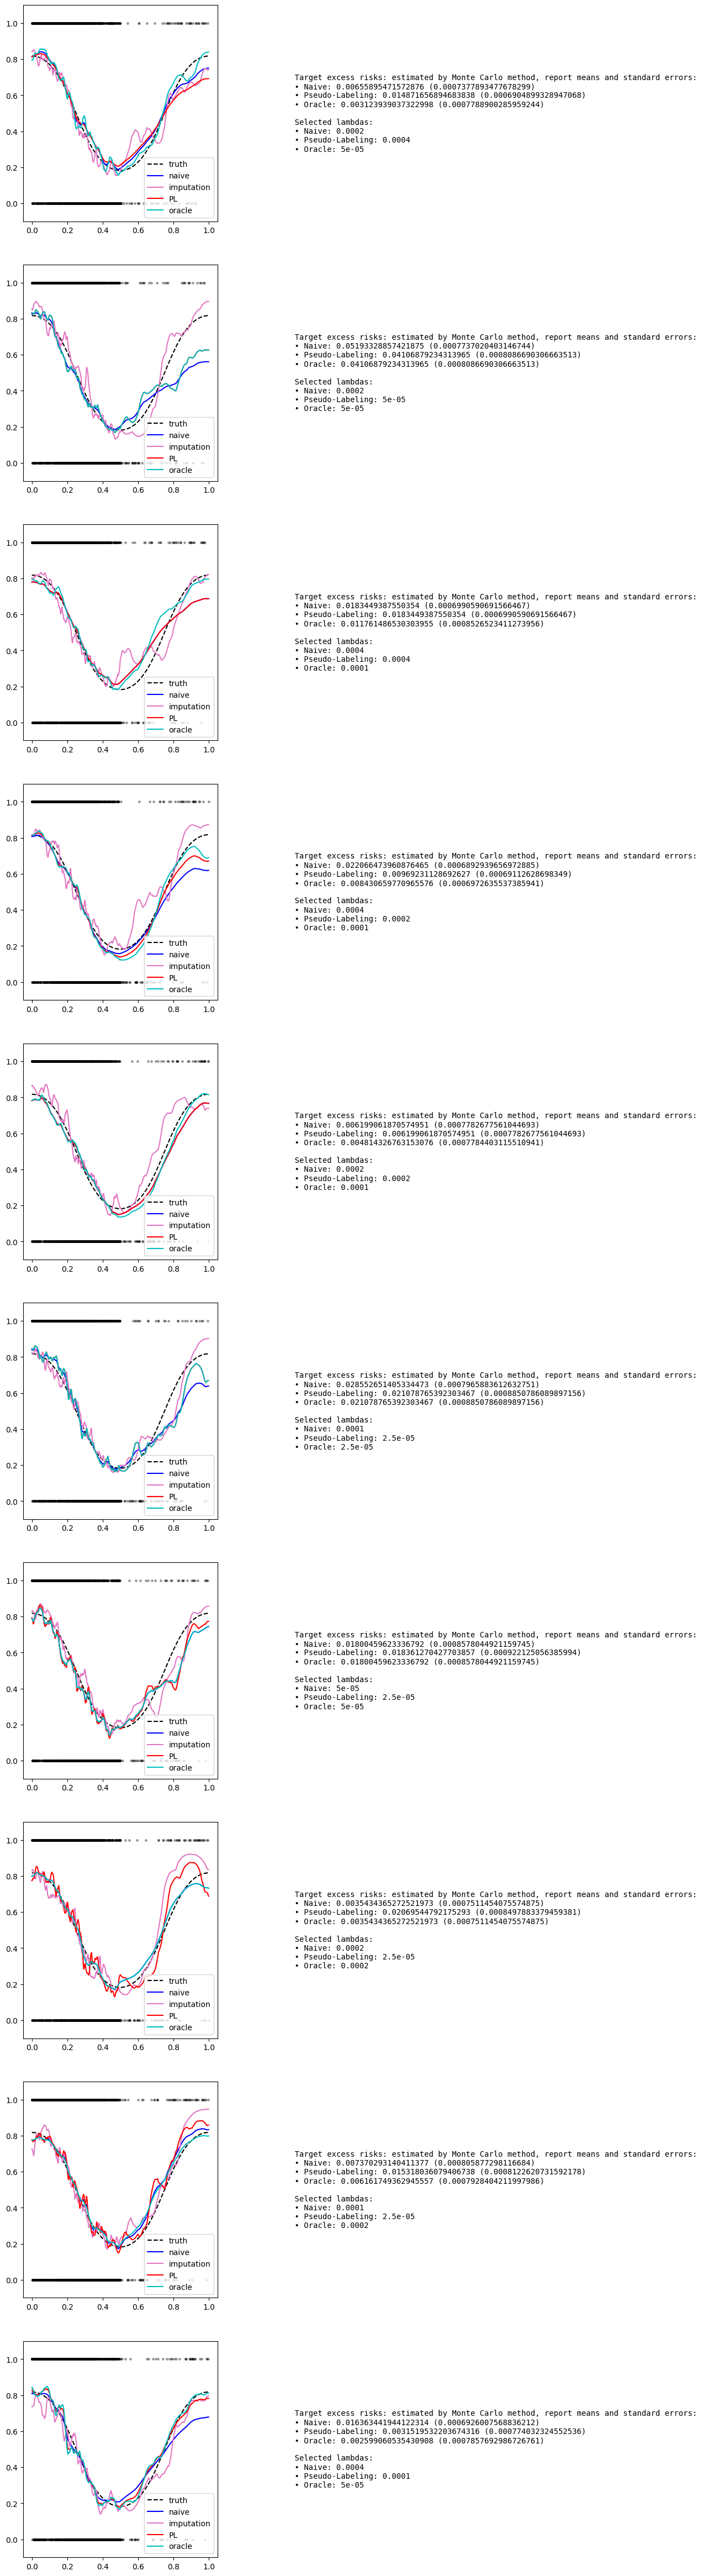

In [ ]:
seed_list = list(range(20, 30))
list_model = []
restot = []

# small, medium, and large penalty parameters
list_idx_candidates = [2, 4, 6]
penalty_size = {0: 'small', 1: 'medium', 2: 'large'}
N_test = 10000 # number of new testing samples for evaluation
xlim = [-0.05, 1.05]
ylim = [-0.1, 1.1]

fig, axs = plt.subplots(ncols=2, nrows=10, figsize=(10, 60))

for k, seed in enumerate(seed_list):
    test = KGLM_covariate_shift(n=n, n_0=n, B=B, fcn=fcn, family='logistic', kernel='sobolev_intercept', seed=seed)
    test.fit(beta = beta)
    list_model.append(test)

    X_new = np.arange(0, 1, 0.001) # grid
    test.predict_final(X_new)

    axs[k, 0].set_ylim(ylim)
    axs[k, 0].set_xlim(xlim)
    axs[k, 0].plot(test.X_1, test.y_1, 'k.', alpha = 0.3, markersize = 5, label = '_nolegend_')
    axs[k, 0].plot(X_new, test.mean_new_true, 'k--', label = 'truth')
    axs[k, 0].plot(X_new, test.mean_new_naive, 'b-', label = 'naive')
    axs[k, 0].plot(X_new, test.mean_new_tilde, color = 'tab:pink', label = 'imputation')
    axs[k, 0].plot(X_new, test.mean_new_pseudo, 'r-', label = 'PL')
    axs[k, 0].plot(X_new, test.mean_new_real, 'c-', label = 'oracle')



    axs[k, 0].legend(loc = 'lower right')

    #####################
    # evaluation
    test.evaluate_final(N_test = N_test, seed = seed)
    axs[k, 1].axis('off')  # Turn off axis

    info_text = f"""
    Target excess risks: estimated by Monte Carlo method, report means and standard errors:
    • Naive: {test.err_naive} ({test.err_naive_ste})
    • Pseudo-Labeling: {test.err_pseudo} ({test.err_pseudo_ste})
    • Oracle: {test.err_real} ({test.err_real_ste})

    Selected lambdas:
    • Naive: {test.lbd_naive}
    • Pseudo-Labeling: {test.lbd_pseudo}
    • Oracle: {test.lbd_real}
    """

    res = np.array([test.err_naive, test.err_pseudo, test.err_real])
    restot.append(res)

    axs[k, 1].text(0.1, 0.5, info_text,
                    transform=axs[k, 1].transAxes,
                    fontsize=10, verticalalignment='center',
                    family='monospace')


restot = np.array(restot)
#np.savetxt('results_general.csv', restot, delimiter=',')

In [ ]:
idx_list = np.arange(1, 11)

#n_list = [2000, 4000, 8000, 16000, 32000]
n_list = [8000, 16000, 32000]

for n in n_list:
    for idx in idx_list:
        if n == 8000 and (idx == 1 or idx == 2):
          continue
        S = 10
        seed_list = np.array(range(1, S + 1)) * 100000 # random seeds
        for i in range(S):
            seed_list[i] = seed_list[i] + (idx - 1) * 1000

        res = run_experiment([n], seed_list, family='poisson', fcn=fcn, kernel='sobolev_intercept')
        fp = os.path.join(outdir, f"{n}_{idx}.txt")
        np.savetxt(fp, res[0])
        print('n {} idx {} finished'.format(n, idx))

    print('sample size {} finished'.format(n))

n 8000 idx 3 finished
n 8000 idx 4 finished
n 8000 idx 5 finished
n 8000 idx 6 finished
n 8000 idx 7 finished
n 8000 idx 8 finished
n 8000 idx 9 finished
n 8000 idx 10 finished
sample size 8000 finished
n 16000 idx 1 finished
n 16000 idx 2 finished


/content/drive/My Drive/Kernel_GLM_bis/pseudo_label_experiment_general_KeOps.py:67: RuntimeWarning: overflow encountered in exp
  return np.exp(theta)


n 16000 idx 3 finished


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:185: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


n 16000 idx 4 finished
n 16000 idx 5 finished
n 16000 idx 6 finished
n 16000 idx 7 finished
n 16000 idx 8 finished
n 16000 idx 9 finished
n 16000 idx 10 finished
sample size 16000 finished
n 32000 idx 1 finished
n 32000 idx 2 finished
n 32000 idx 3 finished
n 32000 idx 4 finished
n 32000 idx 5 finished


In [ ]:
idx_list = np.arange(1, 11)

#n_list = [2000, 4000, 8000, 16000, 32000]
n_list = [32000]

for n in n_list:
    for idx in idx_list:
        S = 10
        seed_list = np.array(range(1, S + 1)) * 100000 # random seeds
        for i in range(S):
            seed_list[i] = seed_list[i] + (idx - 1) * 1000

        res = run_experiment([n], seed_list, family='logistic', fcn=fcn, kernel='sobolev_intercept')
        fp = os.path.join(outdir, f"{n}_{idx}.txt")
        np.savetxt(fp, res[0])
        print('n {} idx {} finished'.format(n, idx))

    print('sample size {} finished'.format(n))

n 32000 idx 1 finished
n 32000 idx 2 finished
n 32000 idx 3 finished
n 32000 idx 4 finished
n 32000 idx 5 finished
n 32000 idx 6 finished
n 32000 idx 7 finished
n 32000 idx 8 finished
n 32000 idx 9 finished
n 32000 idx 10 finished
sample size 32000 finished


In [ ]:
#n_list = [2000, 4000, 8000, 16000, 32000]
n_list = [4000, 8000, 16000, 32000]
#n_list = [2000, 4000, 8000, 16000]
#sys.path.append(path)
idx_list = list(range(1, 11))

res = np.zeros((len(n_list), len(idx_list) * 10, 3))
for (i, n) in enumerate(n_list):
    for (j, idx) in enumerate(idx_list):
        #print(n, idx)
        res[i, (j * 10):(j * 10 + 10), :] = np.loadtxt('/content/drive/My Drive/Kernel_GLM_bis/results_logistic_torchcpu_1_5_cos_0_45_shift/{}_{}.txt'.format(n, idx))


y_original = np.mean(res, axis = 1)
y = np.log(y_original)

x_original = np.array(n_list)
X = np.zeros((len(x_original), 2))
X[:, 0] = 1
X[:, 1] = np.log(x_original)
S = np.linalg.inv(X.T @ X)
W = S @ X.T
H = X @ W

Slopes:  [-0.36027614 -0.43446906 -0.45091866]
Standard errors:  [0.04652653 0.04941646 0.053385  ]


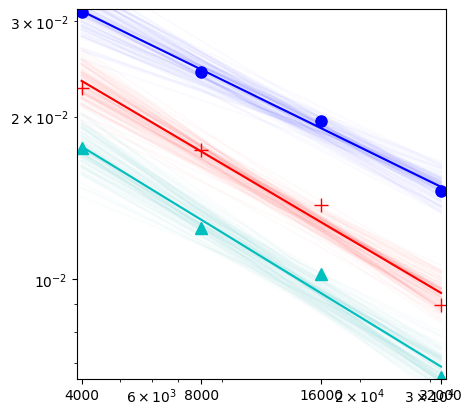

In [ ]:
fig, ax = plt.subplots()

xlim = [np.min(x_original) / 1.03, np.max(x_original) * 1.03]
ylim = [np.min(y_original) / 1.01, np.max(y_original) * 1.01]

plt.ylim(ylim)
plt.xlim(xlim)


plt.plot(x_original, y_original[:, 1], 'r+', markersize = 10) # pseudo-labels
plt.plot(x_original, y_original[:, 2], 'c^', markersize = 8) # real labels
plt.plot(x_original, y_original[:, 0], 'bo', markersize = 8) # naive (source only)


y_pred = H @ y
plt.plot(x_original, np.exp(y_pred[:, 1]), 'r-')
plt.plot(x_original, np.exp(y_pred[:, 2]), 'c-')
plt.plot(x_original, np.exp(y_pred[:, 0]), 'b-')

coef = (W @ y)[1]
print('Slopes: ', coef)


# Uncertainty quantification using bootstrap
alpha = 0.05
q = norm.ppf(1 - alpha / 2)

seed = 10000
B = 10000 # number of bootstrap replicates

np.random.seed(seed)
results_B = np.zeros((B, 2, 3))
m = res.shape[1]

for b in range(B):
    y_b = np.zeros((len(X), 3))
    for j in range(len(res)):
        w = np.random.multinomial(m, np.ones(m) / m)
        w = w / sum(w)
        y_b[j] = (w @ res[j]).reshape(-1,)
    y_b = np.log(y_b)


    if b < 100:
        plt.plot(x_original, np.exp(H @ y_b[:, 1]), 'r-', alpha = 0.02)
        plt.plot(x_original, np.exp(H @ y_b[:, 2]), 'c-', alpha = 0.02)
        plt.plot(x_original, np.exp(H @ y_b[:, 0]), 'b-', alpha = 0.02)


    results_B[b] = W @ y_b


tmp = results_B[:, 1, :]
print( 'Standard errors: ', np.std(tmp, axis = 0) )


ax.set_xscale('log')
ax.set_yscale('log')
ax.set_aspect( (np.log(xlim[1]) - np.log(xlim[0])) / (np.log(ylim[1]) - np.log(ylim[0])) )
plt.xticks(x_original, x_original)
plt.show()

#fig.savefig('krr_errors.pdf', format = 'pdf', transparent=True)


In [ ]:
def f_star(x, fcn): # get true regression function
    if fcn == 'C':
        return np.cos(x * 2 * np.pi) - 1
    if fcn == 'S':
        return np.sin(x * 2 * np.pi)
    if fcn == 'V':
        return np.abs(x - 1/2) - 1/2
    if fcn == 'W':
        f_1 = np.clip( np.abs(4 * x - 1), 0, 1)
        f_2 = np.clip( np.abs(4 * x - 3), 0, 1)
        return f_1 + f_2 - 2
    if fcn == 'x':
        return x * np.sin(4 * np.pi * x)
    if fcn == 'lin':
        return 4 * (x - 0.5)
    if fcn == 'quad':
        return 16*(x-1/2)**2 - 2
    if fcn == 'tan':
        return (np.tan(np.pi*(x-1/2)))**2 - 2
    if fcn == 'abs':
        return 8*np.abs(x-1/2) - 2


#fcn = lambda x : f_star(x, 'abs')

def fcn(x):
    # whatever you had in the lambda:
    return np.cos(x * 2 * np.pi) - 1

In [ ]:
sigma = 1 # standard deviation of noise
beta = 2 # ratio parameter in the grid of lambdas
seed = 100 # random seed
rng = np.random.default_rng(seed)


n = 500 # number of source samples
n_0 = n # number of unlabeled target samples
B = 5 # parameter of distribution shift

test = KGLM_covariate_shift(n, n_0, B, fcn=fcn, family='gaussian', kernel='sobolev', seed=seed, device=device)
test.fit(beta = beta)

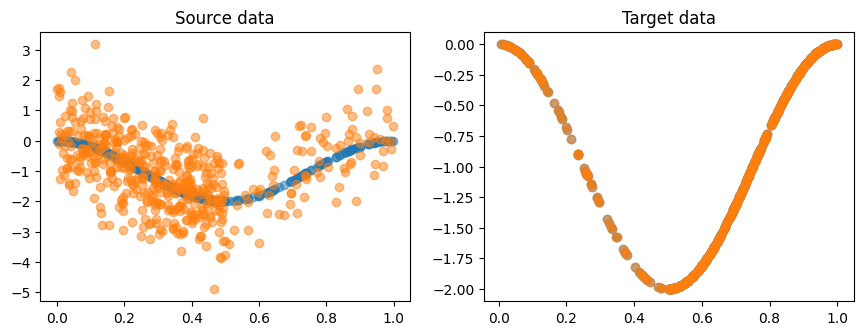

In [ ]:
# Plot the data

fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(10.5, 3.5))

axs[0].plot(test.X, test.mean, 'o', alpha=0.5)
axs[0].plot(test.X, test.y, 'o', alpha=0.5)
axs[0].set_title('Source data')
axs[1].plot(test.X_0, test.mean_0, 'o', alpha=0.5)
axs[1].plot(test.X_0, test.y_0, 'o', alpha=0.5)
axs[1].set_title('Target data')

plt.show()

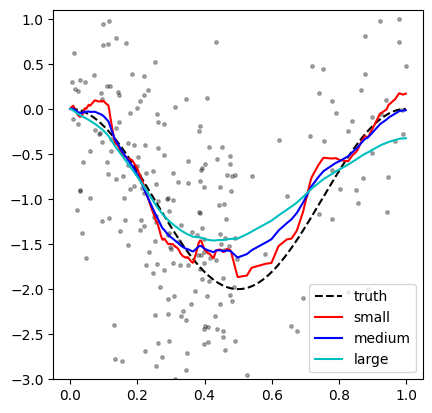

Source and target excess risks: estimated by Monte Carlo method, report means and standard errors
Source: 
Small: -0.7289977669715881 (0.0071310317516326905)
Medium: -0.7298948764801025 (0.007036860585212707)
Large: -0.7119922041893005 (0.006821836233139038)
Best penalty for source: medium

Target: 
Small: -0.7341496348381042 (0.007258217930793762)
Medium: -0.7230277061462402 (0.007009013891220093)
Large: -0.6864733695983887 (0.0067271065711975095)
Best penalty for target: small


In [ ]:
# Visualization and evaluation of candidates
# True function: black dashed line
# Source data: gray dots
# KRR with small penalty: red
# KRR with medium penalty: blue
# KRR with large penalty: cyan


# small, medium, and large penalty parameters
list_idx_candidates = [2, 4, 6]
penalty_size = {0: 'small', 1: 'medium', 2: 'large'}

#####################
# visualize candidates
X_new = np.arange(0, 1, 0.001) # grid
test.predict_candidates(X_new, list_idx_candidates)

fig, ax = plt.subplots()
xlim = [-0.05, 1.05]
ylim = [-3, 1.1]

plt.ylim(ylim)
plt.xlim(xlim)
plt.plot(test.X_1, test.y_1, 'k.', alpha = 0.3, markersize = 5, label = '_nolegend_')
plt.plot(X_new, test.mean_new_true, 'k--', label = 'truth')

plt.plot(X_new, test.mean_new_candidates[0], 'r-', label = 'small')
plt.plot(X_new, test.mean_new_candidates[1], 'b-', label = 'medium')
plt.plot(X_new, test.mean_new_candidates[2], 'c-', label = 'large')
plt.legend(loc = 'lower right')
ax.set_aspect( (xlim[1] - xlim[0]) / (ylim[1] - ylim[0]) )
plt.show()




#####################
# evaluate candidates
print('Source and target excess risks: estimated by Monte Carlo method, report means and standard errors')

# source distribution
N_test = 10000 # number of new testing samples for evaluation
test.evaluate_candidates(distribution = 'source', list_idx_candidates = list_idx_candidates, N_test = N_test, seed=seed)
print('Source: ')
print(f'Small: {test.err_candidates[0]} ({test.err_candidates_ste[0]})')
print(f'Medium: {test.err_candidates[1]} ({test.err_candidates_ste[1]})')
print(f'Large: {test.err_candidates[2]} ({test.err_candidates_ste[2]})')

print(f'Best penalty for source: {penalty_size[np.argmin(test.err_candidates)]}')
print('')

# target distribution
test.evaluate_candidates(distribution = 'target', list_idx_candidates = list_idx_candidates, N_test = N_test, seed=seed)
print('Target: ')
print('Small: {} ({})'.format(test.err_candidates[0], test.err_candidates_ste[0]))
print('Medium: {} ({})'.format(test.err_candidates[1], test.err_candidates_ste[1]))
print('Large: {} ({})'.format(test.err_candidates[2], test.err_candidates_ste[2]))
print(f'Best penalty for target: {penalty_size[np.argmin(test.err_candidates)]}')

Target excess risks: estimated by Monte Carlo method, report means and standard errors
Naive: 0.022849321365356445 (0.007150269150733948)
Pseudo-Labeling: 0.020351529121398926 (0.007258217930793762)
Oracle: 0.020351529121398926 (0.007258217930793762)

Selected lambdas: 
Naive: 0.0016
Pseudo-Labeling: 0.0008
Oracle: 0.0008


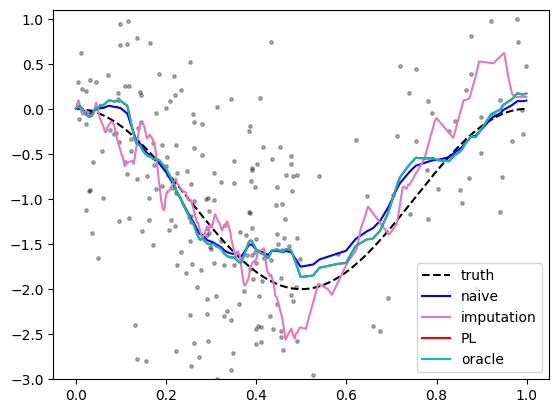

In [ ]:
# Visualization and evaluation of selected models
# True function: black dashed line
# Source data: gray dots
# Naive method (hold-out validation using source data): blue
# Imputation model (undersmoothed): pink
# New method (hold-out validation with pseudo-labels): red
# Oracle method (validation with noiseless true labels): cyan


#####################
# visualization
X_new = np.arange(0, 1, 0.001) # grid
test.predict_final(X_new)

fig, ax = plt.subplots()
xlim = [-0.05, 1.05]
ylim = [-3, 1.1]

plt.ylim(ylim)
plt.xlim(xlim)
plt.plot(test.X_1, test.y_1, 'k.', alpha = 0.3, markersize = 5, label = '_nolegend_')
plt.plot(X_new, test.mean_new_true, 'k--', label = 'truth')
plt.plot(X_new, test.mean_new_naive, 'b-', label = 'naive')
plt.plot(X_new, test.mean_new_tilde, color = 'tab:pink', label = 'imputation')
plt.plot(X_new, test.mean_new_pseudo, 'r-', label = 'PL')
plt.plot(X_new, test.mean_new_real, 'c-', label = 'oracle')

plt.legend(loc = 'lower right')
#ax.set_aspect( (xlim[1] - xlim[0]) / (ylim[1] - ylim[0]) )


#####################
# evaluation
N_test = 10000
test.evaluate_final(N_test = N_test, seed = seed)
print('Target excess risks: estimated by Monte Carlo method, report means and standard errors')
print('Naive: {} ({})'.format(test.err_naive, test.err_naive_ste))
print('Pseudo-Labeling: {} ({})'.format(test.err_pseudo, test.err_pseudo_ste))
print('Oracle: {} ({})'.format(test.err_real, test.err_real_ste))


# report selected lambdas
lbds = [test.lbd_naive, test.lbd_pseudo, test.lbd_real]
print('')
print('Selected lambdas: ')
print('Naive: {}'.format(lbds[0]))
print('Pseudo-Labeling: {}'.format(lbds[1]))
print('Oracle: {}'.format(lbds[2]))

In [ ]:
idx_list = np.arange(1, 11)

n_list = [2000, 4000, 8000, 16000]

for n in n_list:
    for idx in idx_list:
        S = 10
        seed_list = np.array(range(1, S + 1)) * 100000 # random seeds
        for i in range(S):
            seed_list[i] = seed_list[i] + (idx - 1) * 1000

        res = run_experiment([n], seed_list, family='gaussian', fcn=fcn, kernel='sobolev')
        fp = os.path.join(outdir, f"{n}_{idx}.txt")
        np.savetxt(fp, res[0])
        print('n {} idx {} finished'.format(n, idx))

    print('sample size {} finished'.format(n))

n 2000 idx 1 finished
n 2000 idx 2 finished
n 2000 idx 3 finished
n 2000 idx 4 finished
n 2000 idx 5 finished
n 2000 idx 6 finished
n 2000 idx 7 finished
n 2000 idx 8 finished
n 2000 idx 9 finished
n 2000 idx 10 finished
sample size 2000 finished
n 4000 idx 1 finished
n 4000 idx 2 finished
n 4000 idx 3 finished
n 4000 idx 4 finished
n 4000 idx 5 finished
n 4000 idx 6 finished
n 4000 idx 7 finished
n 4000 idx 8 finished
n 4000 idx 9 finished
n 4000 idx 10 finished
sample size 4000 finished
n 8000 idx 1 finished
n 8000 idx 2 finished
n 8000 idx 3 finished
n 8000 idx 4 finished
n 8000 idx 5 finished
n 8000 idx 6 finished
n 8000 idx 7 finished
n 8000 idx 8 finished
n 8000 idx 9 finished
n 8000 idx 10 finished
sample size 8000 finished
n 16000 idx 1 finished
n 16000 idx 2 finished
n 16000 idx 3 finished
n 16000 idx 4 finished
n 16000 idx 5 finished
n 16000 idx 6 finished
n 16000 idx 7 finished
n 16000 idx 8 finished
n 16000 idx 9 finished
n 16000 idx 10 finished
sample size 16000 finished


In [ ]:
idx_list = np.arange(5, 11)

n_list = [32000]

for n in n_list:
    for idx in idx_list:
        S = 10
        seed_list = np.array(range(1, S + 1)) * 100000 # random seeds
        for i in range(S):
            seed_list[i] = seed_list[i] + (idx - 1) * 1000

        res = run_experiment([n], seed_list, family='gaussian', fcn=fcn, kernel='sobolev')
        fp = os.path.join(outdir, f"{n}_{idx}.txt")
        np.savetxt(fp, res[0])
        print('n {} idx {} finished'.format(n, idx))

    print('sample size {} finished'.format(n))

n 32000 idx 5 finished
n 32000 idx 6 finished
n 32000 idx 7 finished
n 32000 idx 8 finished
n 32000 idx 9 finished
n 32000 idx 10 finished
sample size 32000 finished
